# Lung Cancer Detection with CNN-RNN and Explainable AI (Grad-CAM)

This notebook implements a full pipeline for early lung cancer detection using chest X-ray images.  
It employs a hybrid deep learning architecture combining CNNs and RNNs, along with explainability tools.

- **Dataset**: NIH ChestX-ray14  
- **Task**: Binary classification (Cancer Present vs. No Cancer)  
- **Model**:
  - **CNN**: EfficientNetB3 (for feature extraction from chest X-rays and selected ROIs)
  - **RNN**: LSTM (to capture spatial dependencies among ROIs)
  - **Explainability**: Grad-CAM for visualizing salient regions

**Author**: Jose Alberto Cruz Sanchez  
**Date**: July 2025  
**Institution**: National College of Ireland – MSc in Artificial Intelligence

> Early and accurate detection of lung cancer is critical for improving survival rates. This work aims to enhance diagnostic support using interpretable AI.

# 1. Importan Libraries and Setup:

In [879]:
# Standard Library Imports
import os
import csv
import zipfile
from datetime import datetime
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Third-party Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from tqdm.notebook import tqdm
from fpdf import FPDF

# Scikit-learn Metrics
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    auc,
    f1_score,
    precision_recall_curve
)

# PyTorch & TorchVision
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as T
from torchvision import models, transforms
from torchvision.models import densenet121, DenseNet121_Weights

# Explainability Libraries
from captum.attr import LayerGradCam

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


# 2. Define Paths and Load Metadata:

In [880]:
DATA_DIR = r"C:\Users\mishu\Documents\NCI\Practicum Final\archive"
METADATA_PATH = os.path.join(DATA_DIR, 'Data_Entry_2017.csv')
BBOX_PATH = os.path.join(DATA_DIR, 'BBox_List_2017.csv')
IMAGE_SUBDIRS = [f'Images_{i:03d}' for i in range(1, 13)]

# Load Metadata
df_labels = pd.read_csv(METADATA_PATH)
df_bboxes = pd.read_csv(BBOX_PATH)

# Preprocess and merge
df_bboxes.rename(columns={'Image Index': 'Image Index', 'Finding Label': 'Finding Labels'}, inplace=True)
df_labels = pd.merge(df_labels, df_bboxes, on=['Image Index', 'Finding Labels'], how='left')

#Process Labels
all_diseases = sorted(set(label for x in df_labels['Finding Labels'] for label in x.split('|')))
for disease in all_diseases:
    df_labels[disease] = df_labels['Finding Labels'].apply(lambda x: 1 if disease in x else 0)

df_labels['Cancer_Present'] = df_labels[['Mass', 'Nodule']].any(axis=1).astype(int)
df_labels['No Finding'] = df_labels['Finding Labels'].apply(lambda x: 1 if x == 'No Finding' else 0)

# Map image paths
image_paths = {}
for subdir in IMAGE_SUBDIRS:
    current_dir = os.path.join(DATA_DIR, subdir, 'images')
    if os.path.exists(current_dir):
        for img in os.listdir(current_dir):
            if img.endswith('.png'):
                image_paths[img] = os.path.join(current_dir, img)

df_labels['path'] = df_labels['Image Index'].map(image_paths)
df_labels.dropna(subset=['path'], inplace=True)
print(f"Total valid images: {len(df_labels)}")

Total valid images: 112120


# 3. Group, Balance and Create Final Dataset:

In [881]:
# Rename bounding box columns
df_labels.rename(columns={
    'Bbox [x': 'Bbox_X',
    'y': 'Bbox_Y',
    'w': 'Bbox_W',
    'h]': 'Bbox_H'
}, inplace=True)

# Group by 'Image Index' and aggregate
grouped = df_labels.groupby('Image Index').apply(
    lambda x: {
        'path': x['path'].iloc[0],
        'Cancer_Present': x['Cancer_Present'].iloc[0],
        'No Finding': x['No Finding'].iloc[0],
        'bboxes': x.dropna(subset=['Bbox_X', 'Bbox_Y', 'Bbox_W', 'Bbox_H'])[['Bbox_X', 'Bbox_Y', 'Bbox_W', 'Bbox_H']].values.tolist()
        },
        include_groups=False
        ).reset_index()

# Convert to DataFrame
df_final = pd.DataFrame({
    'Image Index': grouped['Image Index'],
    'path': grouped[0].apply(lambda x: x['path']),
    'Cancer_Present': grouped[0].apply(lambda x: x['Cancer_Present']),
    'No Finding': grouped[0].apply(lambda x: x['No Finding']),
    'bboxes': grouped[0].apply(lambda x: x['bboxes'])
})

# Filter Cancer and No Finding only
df_pos = df_final[df_final['Cancer_Present'] == 1]
df_neg = df_final[df_final['No Finding'] == 1].sample(n=len(df_pos), random_state=42)

# Create binary dataset
df_binary = pd.concat([df_pos, df_neg]).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Binary dataset size: {len(df_binary)} Images.")

Binary dataset size: 22414 Images.


# 4. Define Dataset and Collate_fn:

In [882]:
class ChestXRayDataset(Dataset):
    """
    Custom Dataset class for loading Chest X-ray images and associated ROIs.

    Args:
        df (pd.DataFrame): DataFrame with columns ['path', 'Cancer_Present', 'bboxes'].
        transform (callable, optional): Transform to apply to the full image.
        roi_transform (callable, optional): Transform to apply to each ROI.
        max_rois (int): Maximum number of ROIs to extract per image.
    """    
    def __init__(self, df, transform=None, roi_transform=None, max_rois=3):
        self.df = df
        self.transform = transform
        self.roi_transform = roi_transform or transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                 [0.229, 0.224, 0.225])
        ])
        self.max_rois = max_rois # Maximum number of ROIs to extract per image

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            image = Image.open(row["path"]).convert("RGB")
        except Exception as e:
            raise RuntimeError(f"Failed to load image at {row['path']}: {e}")

        bboxes = row["bboxes"]
        label = torch.tensor(row["Cancer_Present"], dtype=torch.float32)

        rois = []
        for bbox in bboxes[:self.max_rois]:  # Limit the number of ROIs
            x, y, w, h = map(int, bbox)
            roi = image.crop((x, y, x + w, y + h))
            rois.append(self.roi_transform(roi))

        # If no ROIs are found, use the transformed image as a fallback
        if not rois:
            rois.append(self.roi_transform(image))

        if self.transform:
            image = self.transform(image)

        return image, rois, torch.as_tensor(label, dtype=torch.float32)


In [883]:
class EarlyStopping:
    """
    Implements early stopping to halt training when validation loss stops improving.

    Args:
        patience (int): Number of consecutive epochs to wait before stopping.
        delta (float): Minimum change in validation loss to qualify as an improvement.
        path (str): Path to save the best model weights.
        verbose (bool): If True, prints status messages to stdout.
    """
    def __init__(self, patience=3, delta=0.0, path='best_model.pth', verbose=True):
        self.patience = patience
        self.delta = delta
        self.path = path
        self.verbose = verbose
        self.best_loss = float('inf')
        self.counter = 0
        self.early_stop = False

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.counter = 0
            torch.save(model.state_dict(), self.path)
            if self.verbose:
                print(f"Validation loss improved. Model saved to {self.path}.")
        else:
            self.counter += 1
            if self.verbose:
                print(f"No improvement. Patience: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        return self.early_stop

# 5. Data Splitting and Dataloaders:

In [884]:
def collate_fn(batch):
    """
    Custom collate function to handle variable number of ROIs per image.
    Pads ROI tensors to match the max number of ROIs in the batch.

    Args:
        batch (list of tuples): Each tuple contains (image, list_of_rois, label)

    Returns:
        images (Tensor): Batch of full images, shape (B, C, H, W)
        padded_rois (Tensor): Padded ROI sequences, shape (B, max_rois, C, H, W)
        labels (Tensor): Corresponding labels (binary)
    """
    images, padded_rois, labels = [], [], []
    
    max_rois = max(len(rois) for _, rois, _ in batch)
    
    for img, rois, label in batch:
        images.append(img)
        
        # Pad ROIs with zero tensors to match max_rois
        padded = rois + [torch.zeros_like(rois[0])] * (max_rois - len(rois))
        padded_rois.append(torch.stack(padded))
        
        labels.append(label)

    return torch.stack(images), torch.stack(padded_rois), torch.stack(labels)

In [885]:
# Split the binary dataset into train, validation, and test sets
train_df, temp_df = train_test_split(
    df_binary,
    test_size=0.3,
    stratify=df_binary["Cancer_Present"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["Cancer_Present"],
    random_state=42
)

print(f"Training set: {len(train_df)} images")
print(f"Validation set: {len(val_df)} images")
print(f"Test set: {len(test_df)} images")

# Define ROI and full-image transforms

# ROI transform with data augmentation
train_roi_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Validation/Test ROI transform (no augmentation)
val_roi_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Full image transform (can be used for Grad-CAM or image-level branch)
image_transform = transforms.Compose([
    transforms.Resize((300, 300)),  # EfficientNetB3 expects 300x300
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Create Dataset objects with a fixed max number of ROIs
MAX_ROIS = 3

train_dataset = ChestXRayDataset(train_df, transform=image_transform, roi_transform=train_roi_transform, max_rois=MAX_ROIS)
val_dataset   = ChestXRayDataset(val_df,   transform=image_transform, roi_transform=val_roi_transform, max_rois=MAX_ROIS)
test_dataset  = ChestXRayDataset(test_df,  transform=image_transform, roi_transform=val_roi_transform, max_rois=MAX_ROIS)

# Create DataLoaders for training and evaluation
BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, num_workers=0)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        collate_fn=collate_fn, num_workers=0)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         collate_fn=collate_fn, num_workers=0)

Training set: 15689 images
Validation set: 3362 images
Test set: 3363 images


# 6. Define Hybrid CNN-RNN Model:

In [886]:
class CNN_RNN_Model(nn.Module):
    """
    Hybrid CNN-RNN model for ROI-based binary classification on chest X-ray images.

    Architecture:
    - CNN backbone: DenseNet121 (pretrained, partial fine-tuning)
    - RNN: LSTM over ROI features
    - Classifier: Fully connected layers without final activation (for BCEWithLogitsLoss)

    Args:
        hidden_dim (int): LSTM hidden dimension
        lstm_layers (int): Number of LSTM layers
        bidirectional (bool): If True, use bidirectional LSTM
    """
    def __init__(self, hidden_dim=128, lstm_layers=1, bidirectional=True):
        super(CNN_RNN_Model, self).__init__()

        # CNN Backbone
        base_model = densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
        self.feature_extractor = base_model.features
        self.pooling = nn.AdaptiveAvgPool2d((1, 1))
        self.feature_dim = 1024  # Output channels from DenseNet121

        # Fine-tune last 2 dense blocks only
        for param in self.feature_extractor.parameters():
            param.requires_grad = False
        for layer in list(self.feature_extractor.children())[-4:]:
            for param in layer.parameters():
                param.requires_grad = True

        # LSTM
        self.lstm = nn.LSTM(
            input_size=self.feature_dim,
            hidden_size=hidden_dim,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=0.3 if lstm_layers > 1 else 0
        )

        lstm_output_dim = hidden_dim * 2 if bidirectional else hidden_dim

        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(lstm_output_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)  # Output logits
        )

    def forward(self, x_rois):
        """
        Args:
            x_rois (Tensor): Tensor of shape (B, N, C, H, W) representing ROIs per image.

        Returns:
            Tensor: Logits of shape (B,)
        """
        B, N, C, H, W = x_rois.shape

        # Flatten batch and ROI dimension to process with CNN
        x = x_rois.view(B * N, C, H, W)

        # Extract features using CNN
        features = self.feature_extractor(x)
        features = self.pooling(features)
        features = features.view(features.size(0), -1)  # Shape: (B*N, feature_dim)

        # Reshape back to (B, N, feature_dim) for LSTM input
        features = features.view(B, N, -1)

        # Pass through LSTM
        lstm_out, _ = self.lstm(features)

        # Use the output of the last ROI (could also try mean pooling)
        last_output = lstm_out[:, -1, :]  # Shape: (B, hidden_dim*2)

        # Final classification
        out = self.classifier(last_output)  # Shape: (B, 1)
        return out.squeeze(1)  # Shape: (B,)

# Model Sanity Check

In [887]:
# Sanity Check: Forward Pass with a Mini-batch

# Instantiate the model and move it to the selected device
model = CNN_RNN_Model().to(device)
model.eval()  # Set model to evaluation mode

# Get one mini-batch from the training data
images, rois_batch, labels = next(iter(train_loader))

print(f"Images shape:       {images.shape}")      # (B, C, H, W)
print(f"ROIs batch shape:   {rois_batch.shape}")  # (B, N, C, H, W)
print(f"Labels shape:       {labels.shape}")      # (B,)

# Move data to the same device as the model
rois_batch = rois_batch.to(device)
labels = labels.to(device)

# Disable gradient tracking for inference
with torch.no_grad():
    outputs = model(rois_batch)

# Output shapes and sample predictions
print(f"Model output shape: {outputs.shape}")      # (B,)
print(f"Sample outputs:     {outputs[:5].cpu().numpy()}")  # Raw logits

probs = torch.sigmoid(outputs)
print(f"Probabilities: {probs[:5].cpu().numpy()}")

Images shape:       torch.Size([16, 3, 300, 300])
ROIs batch shape:   torch.Size([16, 1, 3, 224, 224])
Labels shape:       torch.Size([16])
Model output shape: torch.Size([16])
Sample outputs:     [0.14100565 0.18685861 0.14583509 0.17567718 0.17136297]
Probabilities: [0.53519315 0.5465792  0.5363943  0.5438067  0.54273623]


# 7. Model Training:

In [888]:
class FocalLoss(nn.Module):
    """
    Implements the binary Focal Loss function.
    
    Focal Loss = α * (1 - pt)^γ * BCE, where:
        - pt is the probability of the true class
        - α balances positive vs. negative examples
        - γ focuses learning on hard examples

    Args:
        alpha (float): Weighting factor for class imbalance (usually 0.25 for rare class).
        gamma (float): Focusing parameter (commonly set to 2.0).
        reduction (str): Specifies reduction method: 'mean', 'sum', or 'none'.
    """
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.bce = nn.BCEWithLogitsLoss(reduction='none')  # We'll apply custom weighting

    def forward(self, inputs, targets):
        targets = targets.float()  # Ensure correct dtype
        bce_loss = self.bce(inputs, targets)

        # Convert logits to probabilities
        probs = torch.sigmoid(inputs)

        # pt is the predicted probability of the true class
        pt = probs * targets + (1 - probs) * (1 - targets)

        # Focal loss term
        focal_term = self.alpha * (1 - pt) ** self.gamma
        loss = focal_term * bce_loss

        # Reduction
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss  # shape: (B,)

In [889]:
# Metric computation
def compute_metrics(preds, labels):
    preds = torch.sigmoid(preds).detach().cpu().numpy()
    labels = labels.detach().cpu().numpy()
    preds_bin = (preds >= 0.5).astype(int)

    acc = accuracy_score(labels, preds_bin)
    auc = roc_auc_score(labels, preds)
    return acc, auc

# Optional pos_weight (not used in FocalLoss, kept for reference)
class_counts = df_labels['Cancer_Present'].value_counts()
neg_count, pos_count = class_counts[0], class_counts[1]
pos_weight_value = neg_count / pos_count
pos_weight_tensor = torch.tensor([pos_weight_value], dtype=torch.float32, device=device)

print(f"[INFO] pos_weight = {pos_weight_value:.4f}  (neg={neg_count}, pos={pos_count})")

# Initialize model, loss, optimizer, early stopping 
model = CNN_RNN_Model().to(device)
criterion = FocalLoss(alpha=0.25, gamma=2.0)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
early_stopper = EarlyStopping(patience=3, delta=0.001,path='best_model.pth')

# History tracking 
train_losses, val_losses = [], []
train_accs, val_accs = [], []
train_aucs, val_aucs = [], []

# Training loop
num_epochs = 30
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    preds_all, labels_all = [], []

    for img, rois, lbl in train_loader:
        rois = rois.to(device)
        lbl = lbl.to(device).float()

        optimizer.zero_grad()
        out = model(rois)
        loss = criterion(out, lbl)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        preds_all.append(out)
        labels_all.append(lbl)

    # Training metrics
    avg_loss = epoch_loss / len(train_loader)
    preds_all = torch.cat(preds_all)
    labels_all = torch.cat(labels_all)
    train_acc, train_auc = compute_metrics(preds_all, labels_all)

    train_losses.append(avg_loss)
    train_accs.append(train_acc)
    train_aucs.append(train_auc)

    # Validation loop 
    model.eval()
    val_loss = 0.0
    val_preds_all, val_labels_all = [], []

    with torch.no_grad():
        for img, rois, lbl in val_loader:
            rois = rois.to(device)
            lbl = lbl.to(device).float()
            out = model(rois)
            loss = criterion(out, lbl)
            val_loss += loss.item()
            val_preds_all.append(out)
            val_labels_all.append(lbl)

    avg_val_loss = val_loss / len(val_loader)
    val_preds_all = torch.cat(val_preds_all)
    val_labels_all = torch.cat(val_labels_all)
    val_acc, val_auc = compute_metrics(val_preds_all, val_labels_all)

    val_losses.append(avg_val_loss)
    val_accs.append(val_acc)
    val_aucs.append(val_auc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {avg_loss:.4f}, Val Loss: {avg_val_loss:.4f} | "
          f"Train Acc: {train_acc:.4f}, AUC: {train_auc:.4f} | "
          f"Val Acc: {val_acc:.4f}, AUC: {val_auc:.4f}")

    # Apply early stopping only when validation loss has not improved for 'patience' epochs 
    if early_stopper(avg_val_loss, model):
        print("Early stopping triggered.")
        break   

[INFO] pos_weight = 9.0045  (neg=100913, pos=11207)
Epoch [1/30] Train Loss: 0.0385, Val Loss: 0.0371 | Train Acc: 0.6708, AUC: 0.7309 | Val Acc: 0.7014, AUC: 0.7686
Validation loss improved. Model saved to best_model.pth.
Epoch [2/30] Train Loss: 0.0365, Val Loss: 0.0350 | Train Acc: 0.7053, AUC: 0.7707 | Val Acc: 0.7296, AUC: 0.7924
Validation loss improved. Model saved to best_model.pth.
Epoch [3/30] Train Loss: 0.0354, Val Loss: 0.0356 | Train Acc: 0.7200, AUC: 0.7892 | Val Acc: 0.7082, AUC: 0.7981
No improvement. Patience: 1/3
Epoch [4/30] Train Loss: 0.0347, Val Loss: 0.0355 | Train Acc: 0.7306, AUC: 0.8010 | Val Acc: 0.7311, AUC: 0.7982
No improvement. Patience: 2/3
Epoch [5/30] Train Loss: 0.0340, Val Loss: 0.0347 | Train Acc: 0.7397, AUC: 0.8105 | Val Acc: 0.7308, AUC: 0.8007
No improvement. Patience: 3/3
Early stopping triggered.


Best threshold found: 0.5032 (J-score: 0.4658)

Final Evaluation with Optimized Threshold:
Accuracy:     0.7326
Precision:    0.7689
Recall:       0.6651
F1-score:     0.7132
AUC:          0.7924
Specificity:  0.8001
NPV:          0.7049
Confusion Matrix:
[[TN FP]
 [FN TP]]
[[1345 336]
 [563 1118]]
Prediction results saved to 'prediction_results.csv'.
Summary metrics saved to 'final_metrics.csv'.


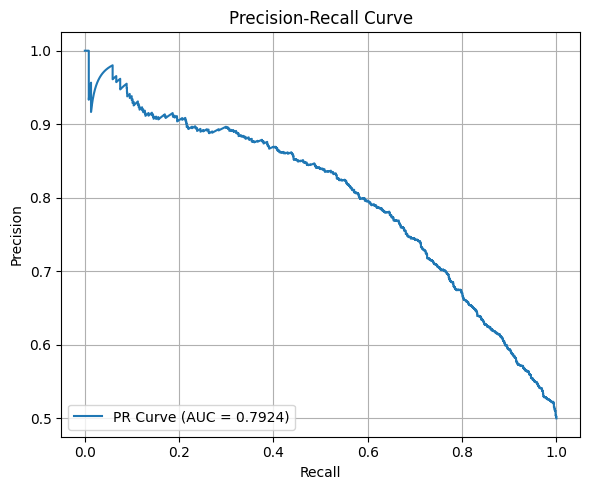

Precision-Recall curve saved as 'precision_recall_curve.png'.


In [890]:
def find_best_threshold(y_true, y_probs):
    """
    Computes the optimal threshold using Youden’s J-statistic (TPR - FPR).
    """
    fpr, tpr, thresholds = roc_curve(y_true, y_probs)
    j_scores = tpr - fpr
    best_thresh = thresholds[j_scores.argmax()]
    return best_thresh, j_scores.max()

# Load the trained model
model = CNN_RNN_Model().to(device)
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.eval()

# Predict on validation set
all_probs = []
all_labels = []

with torch.no_grad():
    for _, rois, lbl in val_loader:
        rois = rois.to(device)
        lbl = lbl.to(device).float()
        outputs = model(rois)
        probs = torch.sigmoid(outputs)
        all_probs.extend(probs.cpu().numpy().flatten())
        all_labels.extend(lbl.cpu().numpy().flatten())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# Find best threshold using J-statistic
best_thresh, j_score = find_best_threshold(all_labels, all_probs)
print(f"Best threshold found: {best_thresh:.4f} (J-score: {j_score:.4f})")

# Apply threshold
all_preds = (all_probs > best_thresh).astype(int)

# Confusion Matrix and Metrics
tn, fp, fn, tp = confusion_matrix(all_labels, all_preds).ravel()
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs)
specificity = tn / (tn + fp)
npv = tn / (tn + fn)

print("\nFinal Evaluation with Optimized Threshold:")
print(f"Accuracy:     {accuracy:.4f}")
print(f"Precision:    {precision:.4f}")
print(f"Recall:       {recall:.4f}")
print(f"F1-score:     {f1:.4f}")
print(f"AUC:          {auc:.4f}")
print(f"Specificity:  {specificity:.4f}")
print(f"NPV:          {npv:.4f}")
print(f"Confusion Matrix:\n[[TN FP]\n [FN TP]]\n[[{tn} {fp}]\n [{fn} {tp}]]")

# Save predictions
results_df = pd.DataFrame({
    'true_label': all_labels,
    'predicted_label': all_preds,
    'predicted_prob': all_probs
})
results_df.to_csv('prediction_results.csv', index=False)
print("Prediction results saved to 'prediction_results.csv'.")

# Save summary metrics
metrics_dict = {
    'Threshold': [best_thresh],
    'J-Score': [j_score],
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F1-score': [f1],
    'AUC': [auc],
    'Specificity': [specificity],
    'NPV': [npv],
    'TN': [tn], 'FP': [fp], 'FN': [fn], 'TP': [tp]
}
metrics_df = pd.DataFrame(metrics_dict)
metrics_df.to_csv('final_metrics.csv', index=False)
print("Summary metrics saved to 'final_metrics.csv'.")

# Plot and save Precision-Recall curve
precision_vals, recall_vals, _ = precision_recall_curve(all_labels, all_probs)
plt.figure(figsize=(6, 5))
plt.plot(recall_vals, precision_vals, label=f'PR Curve (AUC = {auc:.4f})')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.legend(loc="lower left")
plt.tight_layout()
plt.savefig("precision_recall_curve.png", dpi=300, bbox_inches='tight')
plt.show()
print("Precision-Recall curve saved as 'precision_recall_curve.png'.")


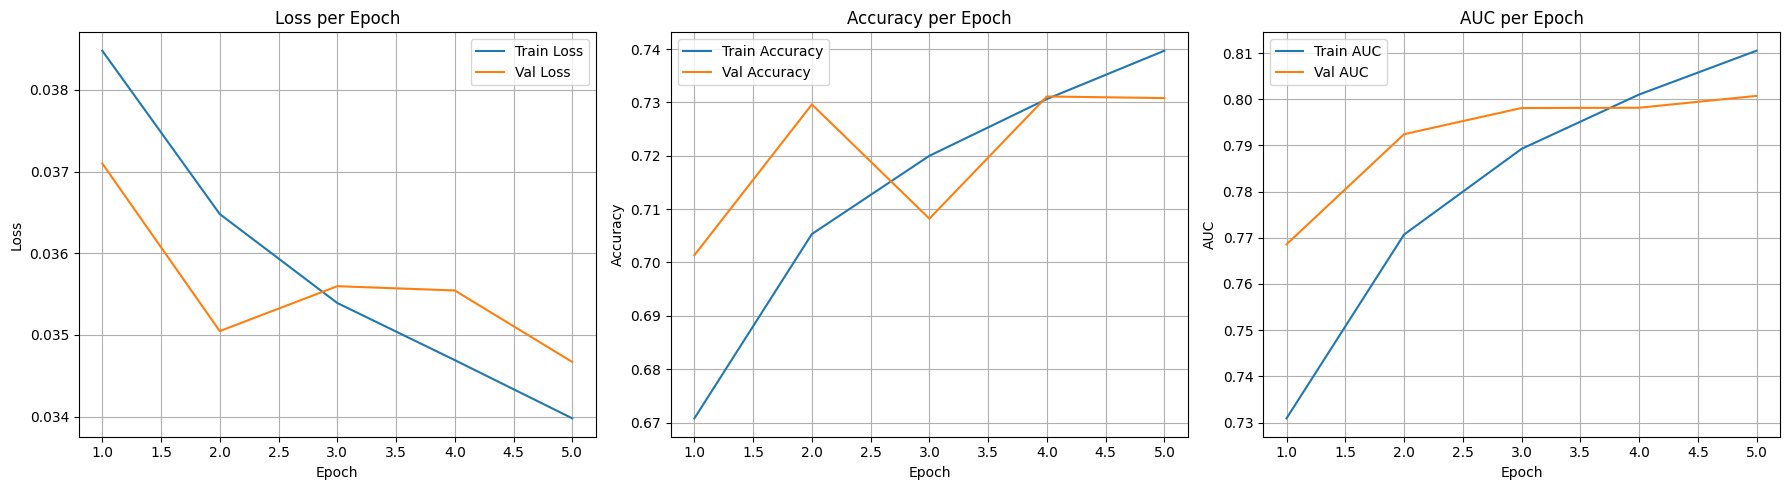

In [891]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(18, 5))

# Loss
plt.subplot(1, 3, 1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss per Epoch')
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1, 3, 2)
plt.plot(epochs, train_accs, label='Train Accuracy')
plt.plot(epochs, val_accs, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy per Epoch')
plt.legend()
plt.grid(True)

# AUC
plt.subplot(1, 3, 3)
plt.plot(epochs, train_aucs, label='Train AUC')
plt.plot(epochs, val_aucs, label='Val AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.title('AUC per Epoch')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=300)
plt.show()

## 8. Evaluation and Grad-CAM:

In [892]:
def evaluate_model(model, loader, save_path="prediction_results.csv", threshold=0.5, save_csv=True):
    """
    Evaluate the model on a given DataLoader and optionally save predictions to CSV.

    Args:
        model (torch.nn.Module): Trained model.
        loader (DataLoader): DataLoader for test/val set.
        save_path (str): Path to save CSV file.
        threshold (float): Decision threshold for binary classification.
        save_csv (bool): Whether to save results to CSV.

    Returns:
        targets (np.ndarray): Ground truth labels.
        preds (np.ndarray): Predicted probabilities.
    """
    model.eval()
    preds, targets = [], []

    with torch.no_grad():
        for img, rois, lbl in loader:
            rois = rois.to(device)
            lbl = lbl.to(device).float()

            # Ensure correct shape [B, N, C, H, W]
            if rois.ndim == 4:
                rois = rois.unsqueeze(1)  # Add N=1 dimension
            elif rois.ndim != 5:
                raise ValueError(f"Expected input of shape [B, N, C, H, W], but got {rois.shape}")

            outputs = model(rois)
            probs = torch.sigmoid(outputs).cpu().numpy().flatten()
            preds.extend(probs)
            targets.extend(lbl.cpu().numpy().flatten())

    preds = np.array(preds)
    targets = np.array(targets)
    binary_preds = (preds > threshold).astype(int)

    # Compute metrics
    accuracy = accuracy_score(targets, binary_preds)
    precision = precision_score(targets, binary_preds)
    recall = recall_score(targets, binary_preds)
    f1 = f1_score(targets, binary_preds)
    auc = roc_auc_score(targets, preds)

    print("\n--- Evaluation Results ---")
    print(f"AUC:       {auc:.4f}")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")

    # Save predictions to CSV
    if save_csv:
        df = pd.DataFrame({
            "True_Label": targets,
            "Predicted_Label": binary_preds,
            "Probability": preds
        })
        df.to_csv(save_path, index=False)
        print(f"\nResults saved to: {save_path}")

    return targets, preds


In [893]:
evaluate_model(model, test_loader, threshold=best_thresh, save_path="test_predictions.csv")



--- Evaluation Results ---
AUC:       0.7889
Accuracy:  0.7196
Precision: 0.7531
Recall:    0.6532
F1-score:  0.6996

Results saved to: test_predictions.csv


(array([0., 1., 0., ..., 0., 1., 0.], dtype=float32),
 array([0.6299989 , 0.59600216, 0.5444887 , ..., 0.48562923, 0.5559959 ,
        0.36376208], dtype=float32))

## 9. ROC Curve

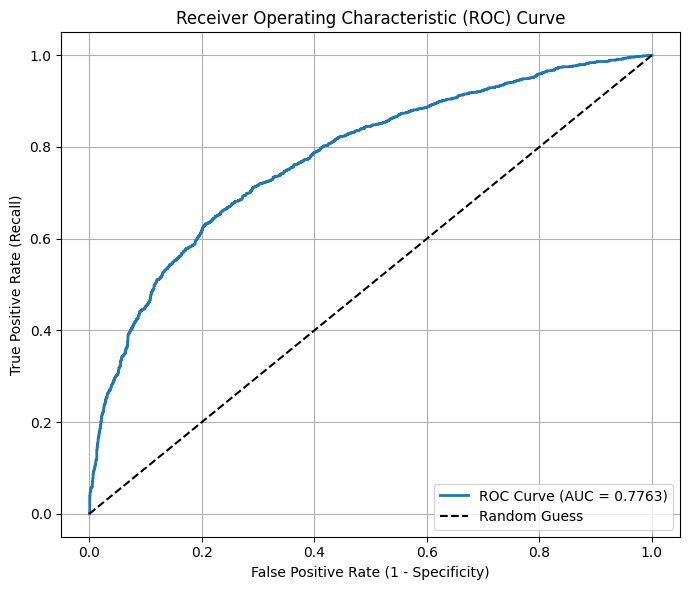

In [894]:
fpr, tpr, thresholds = roc_curve(targets, preds)
roc_auc = roc_auc_score(targets, preds)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})", linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Recall)")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=300)
plt.show()

## 10. Set up Grad-CAM

In [895]:
target_layer = model.feature_extractor[-1]  # Last convolutional layer
gradcam = LayerGradCam(model, target_layer)

## Grad-CAM: Multiple ROIs

In [896]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.model.eval()
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self._hook_layers()

    def _hook_layers(self):
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        def forward_hook(module, input, output):
            self.activations = output.detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor, class_idx=None):
        """
        Generates a Grad-CAM heatmap for a single input tensor [1, C, H, W].
        Assumes a hybrid CNN-RNN model where CNN feeds into an LSTM.
        """
        self.model.zero_grad()

        # Forward through CNN
        B, C, H, W = input_tensor.shape
        features = self.model.feature_extractor(input_tensor)  # shape: [1, C_feat, H', W']

        # Global Pooling 
        pooled = self.model.pooling(features)
        pooled = pooled.view(pooled.size(0), -1)  # shape: [1, feat_dim]

        # Forward through RNN 
        pooled = pooled.view(1, 1, -1)  # [batch, seq_len, features]
        lstm_out, _ = self.model.lstm(pooled)
        last_output = lstm_out[:, -1, :]
        output = self.model.classifier(last_output)  # shape: [1, 1]

        # Backward pass to get gradients
        if class_idx is None:
            class_idx = output.argmax(dim=1)

        output[0].backward(retain_graph=True)  # Binary output → scalar

        # Compute Grad-CAM
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        activations = self.activations[0]  # Get first sample's activations

        for i in range(activations.shape[0]):
            activations[i, :, :] *= pooled_gradients[i]

        heatmap = torch.mean(activations, dim=0).cpu().numpy()
        heatmap = np.maximum(heatmap, 0)
        if np.max(heatmap) > 0:
            heatmap /= np.max(heatmap)

        return heatmap

In [897]:
def overlay_heatmap(heatmap, image_tensor, alpha=0.25, unnormalize=True):
    """
    Superimpose a Grad-CAM heatmap on a given image tensor.

    Args:
        heatmap (np.ndarray): 2D heatmap array (values between 0 and 1).
        image_tensor (torch.Tensor): Tensor of shape [C, H, W].
        alpha (float): Opacity of the heatmap overlay.
        unnormalize (bool): If True, reverse ImageNet normalization.

    Returns:
        np.ndarray: Superimposed BGR image (uint8).
    """
    image = image_tensor.clone().detach().cpu()

    if unnormalize:
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        image = image * std + mean

    image = image.permute(1, 2, 0).numpy()  # [H, W, C]
    image = np.clip(image, 0, 1)
    image = np.uint8(255 * image)

    heatmap_resized = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
    heatmap_resized = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

    superimposed = cv2.addWeighted(image, 1 - alpha, heatmap_color, alpha, 0)
    return superimposed

In [898]:
print(type(model))


<class '__main__.CNN_RNN_Model'>


In [899]:
def visualize_multiple_rois(model, dataloader, target_layer, class_names=None, n_images=3, save_dir='gradcam_outputs'):
    gradcam = GradCAM(model, target_layer)
    model.eval()
    shown = 0

    os.makedirs(save_dir, exist_ok=True)
    index_csv_path = os.path.join(save_dir, "index.csv")

    # Create CSV file to log results
    with open(index_csv_path, mode='w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(["sample_id", "filename_png", "filename_pdf", "label", "timestamp"])

        for image_tensor, rois_tensor, label in dataloader:
            for i in range(rois_tensor.size(0)):
                sample_rois = rois_tensor[i]  # (N, C, H, W)
                sample_label = int(label[i].item())

                if sample_label != 1:
                    continue

                print(f"Sample {shown+1} - Cancer Positive")
                fig, axs = plt.subplots(1, sample_rois.size(0), figsize=(4 * sample_rois.size(0), 4))

                if sample_rois.size(0) == 1:
                    axs = [axs]

                for j in range(sample_rois.size(0)):
                    roi = sample_rois[j].unsqueeze(0).to(device)
                    heatmap = gradcam.generate(roi)
                    overlay = overlay_heatmap(heatmap, sample_rois[j].cpu(), alpha=0.25)

                    axs[j].imshow(overlay)
                    axs[j].axis('off')
                    axs[j].set_title(f'ROI {j+1}')

                plt.tight_layout()

                # Save the figure
                filename_base = os.path.join(save_dir, f"gradcam_sample_{shown+1}")
                png_path = f"{filename_base}.png"
                pdf_path = f"{filename_base}.pdf"
                plt.savefig(png_path, bbox_inches='tight', dpi=300)
                plt.savefig(pdf_path, bbox_inches='tight')
                plt.show()

                print(f"Saved: {png_path} and .pdf")

                # Log the results in CSV
                timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
                writer.writerow([shown+1, png_path, pdf_path, sample_label, timestamp])

                shown += 1
                if shown >= n_images:
                    return

In [900]:
def zip_gradcam_outputs(output_dir='gradcam_outputs', zip_name='gradcam_results.zip'):
    """
    Compresses the contents of a Grad-CAM output directory into a ZIP file.

    Args:
        output_dir (str): Directory containing Grad-CAM results (e.g., .png, .pdf, CSV).
        zip_name (str): Name of the output zip file.

    Returns:
        None
    """
    import zipfile
    import os

    if not os.path.exists(output_dir):
        print(f"Output directory not found: {output_dir}")
        return

    with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(output_dir):
            for file in files:
                filepath = os.path.join(root, file)
                arcname = os.path.relpath(filepath, start=output_dir)
                zipf.write(filepath, arcname=arcname)

    print(f"Results zipped to: {zip_name}")

In [901]:
def get_last_conv_layer(feature_extractor):
    """
    Returns the last nn.Conv2d layer inside the model's CNN feature extractor.

    Args:
        feature_extractor (nn.Sequential or nn.Module): CNN part of the model.

    Returns:
        nn.Conv2d: The last convolutional layer found.

    Raises:
        ValueError: If no nn.Conv2d layer is found.
    """
    for name, module in reversed(list(feature_extractor.named_modules())):
        if isinstance(module, nn.Conv2d):
            print(f"Selected target layer: {name} ({module.__class__.__name__})")
            return module
    raise ValueError("No Conv2d layer found in feature extractor.")

Selected target layer: denseblock4.denselayer16.conv2 (Conv2d)
Sample 1 - Cancer Positive


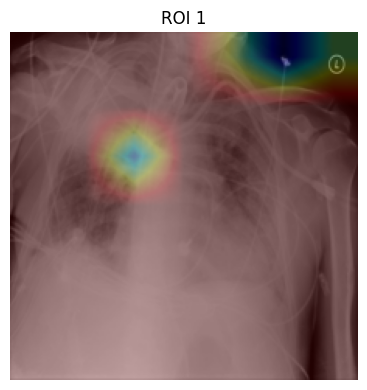

Saved: gradcam_outputs\gradcam_sample_1.png and .pdf
Sample 2 - Cancer Positive


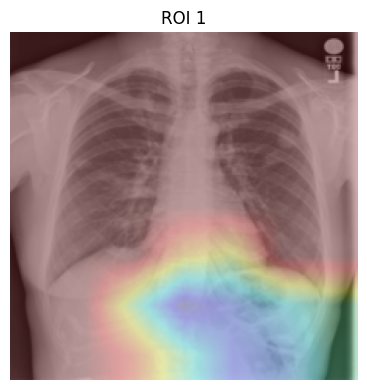

Saved: gradcam_outputs\gradcam_sample_2.png and .pdf
Sample 3 - Cancer Positive


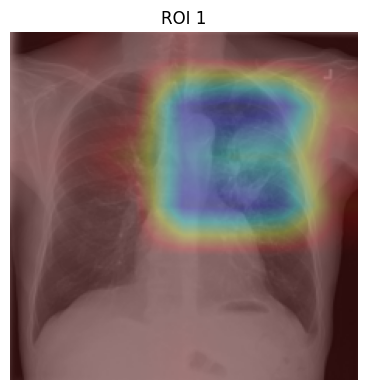

Saved: gradcam_outputs\gradcam_sample_3.png and .pdf
Results zipped to: gradcam_results.zip


In [902]:
# Instantiate and load best model
cnn_rnn_model = CNN_RNN_Model().to(device)
cnn_rnn_model.load_state_dict(torch.load('best_model.pth', map_location=device))
cnn_rnn_model.eval()

# Get target layer for Grad-CAM
target_layer = get_last_conv_layer(cnn_rnn_model.feature_extractor)

# Visualize Grad-CAM for cancer-positive test samples
visualize_multiple_rois(
    model=cnn_rnn_model,
    dataloader=test_loader,
    target_layer=target_layer,
    class_names=['No Cancer', 'Cancer'],
    n_images=3
)

# Zip and save all Grad-CAM results
zip_gradcam_outputs()

In [903]:
for name, module in model.feature_extractor.named_modules():
    print(f"{name} : {module.__class__.__name__}")


 : Sequential
conv0 : Conv2d
norm0 : BatchNorm2d
relu0 : ReLU
pool0 : MaxPool2d
denseblock1 : _DenseBlock
denseblock1.denselayer1 : _DenseLayer
denseblock1.denselayer1.norm1 : BatchNorm2d
denseblock1.denselayer1.relu1 : ReLU
denseblock1.denselayer1.conv1 : Conv2d
denseblock1.denselayer1.norm2 : BatchNorm2d
denseblock1.denselayer1.relu2 : ReLU
denseblock1.denselayer1.conv2 : Conv2d
denseblock1.denselayer2 : _DenseLayer
denseblock1.denselayer2.norm1 : BatchNorm2d
denseblock1.denselayer2.relu1 : ReLU
denseblock1.denselayer2.conv1 : Conv2d
denseblock1.denselayer2.norm2 : BatchNorm2d
denseblock1.denselayer2.relu2 : ReLU
denseblock1.denselayer2.conv2 : Conv2d
denseblock1.denselayer3 : _DenseLayer
denseblock1.denselayer3.norm1 : BatchNorm2d
denseblock1.denselayer3.relu1 : ReLU
denseblock1.denselayer3.conv1 : Conv2d
denseblock1.denselayer3.norm2 : BatchNorm2d
denseblock1.denselayer3.relu2 : ReLU
denseblock1.denselayer3.conv2 : Conv2d
denseblock1.denselayer4 : _DenseLayer
denseblock1.denselayer

In [904]:
def generate_gradcam_report(csv_path='gradcam_outputs/index.csv', output_pdf='gradcam_report.pdf'):
    """
    Generates a PDF report from Grad-CAM results, including one page per sample with metadata and image.

    Args:
        csv_path (str): Path to the CSV file containing Grad-CAM output metadata.
        output_pdf (str): Path to the output PDF file to be saved.

    Returns:
        None
    """
    df = pd.read_csv(csv_path)
    pdf = FPDF(orientation='P', unit='mm', format='A4')
    
    # Cover page
    pdf.add_page()
    pdf.set_font("Arial", "B", 20)
    pdf.cell(0, 10, "Grad-CAM Report for Lung Cancer Detection", ln=True, align='C')
    pdf.ln(10)
    pdf.set_font("Arial", "", 14)
    pdf.cell(0, 10, f"Generated on: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}", ln=True, align='C')
    pdf.ln(20)

    # Add each sample as a new page
    for _, row in df.iterrows():
        pdf.add_page()
        pdf.set_font("Arial", "B", 14)
        pdf.cell(0, 10, f"Sample {int(row['sample_id'])}", ln=True)
        pdf.set_font("Arial", "", 12)
        pdf.cell(0, 8, f"Label: {row['label']}", ln=True)
        pdf.cell(0, 8, f"Timestamp: {row['timestamp']}", ln=True)
        pdf.cell(0, 8, f"File: {row['filename_png']}", ln=True)
        pdf.ln(5)

        # Add image
        try:
            img = Image.open(row['filename_png'])
            img_path = row['filename_png']
            img_width, img_height = img.size
            aspect_ratio = img_height / img_width
            pdf_width = 180  # width in mm
            pdf_height = pdf_width * aspect_ratio
            pdf.image(img_path, x=15, y=pdf.get_y(), w=pdf_width, h=pdf_height)
        except Exception as e:
            pdf.cell(0, 10, f"Error loading image: {e}", ln=True)

    pdf.output(output_pdf)
    print(f"PDF generated: {output_pdf}")

In [905]:
generate_gradcam_report()

PDF generated: gradcam_report.pdf
